# Ensemble Weather Model — Prototype

Bias-correction ensemble over MetOffice / OpenMeteo-ECMWF / OpenMeteo-GFSHRRR / AccuWeather. Predicts temperature, wind speed (and later rain, wind direction) for each forecast horizon. Compares scikit-learn Ridge & RandomForest against LightGBM.

**Inputs**: the 4 model forecasts, lag observations, time, location, and forecast-evolution features.
**Targets**: observed Temperature, WindSpeed (extend to RainProbability, RainVolume, WindDirection later).
**Split**: time-based holdout (older 80% train, newest 20% test).

## 0. Setup

In [51]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print('lightgbm not installed — install with: pip install lightgbm')

load_dotenv()
engine = create_engine(os.environ['DATABASE_URL'])

MODELS = ['MetOffice', 'OpenMeteo-ECMWF', 'OpenMeteo-GFSHRRR', 'AccuWeather']
MPH_TO_KMH = 1.609344

## 0b. Helpers

Functions reused across the Short, Long, and Daily pipelines. The notebook below calls these rather than inlining the logic per cell.

In [52]:
# Column groups used by the pivots
INDEX_COLS = ['city', 'Date', 'Time', 'ForecastTaken', 'hours_ahead',
              'obs_temperature', 'obs_windspeed_kmh', 'obs_winddir', 'obs_maxrainfall']
VALUE_COLS = ['fc_temperature', 'fc_windspeed_kmh', 'fc_winddir', 'fc_rainprob', 'fc_rainvol']


def _flatten_pivot_cols(df):
    df.columns = [
        f'{c[1]}_{c[0]}' if isinstance(c, tuple) and c[1] else (c[0] if isinstance(c, tuple) else c)
        for c in df.columns
    ]
    return df


def build_pivot(raw_df, models_to_pivot, require_models=None, hours_filter=None,
                index_cols=INDEX_COLS, value_cols=VALUE_COLS):
    """Pivot the raw long join into one row per (city, target, ForecastTaken).

    models_to_pivot: only these models become columns
    require_models: drop rows where any of these models lacks a temperature/mintemp forecast
    hours_filter: (lo, hi) inclusive range on hours_ahead, or None for no filter
    """
    df = raw_df[raw_df['Model'].isin(models_to_pivot)]
    pivoted = (df.pivot_table(index=index_cols, columns='Model',
                              values=value_cols, aggfunc='first')
                 .reset_index())
    pivoted = _flatten_pivot_cols(pivoted)

    if require_models:
        # Use whichever 'temperature-like' column the value_cols set provides
        temp_like = next((c for c in ('fc_temperature', 'fc_mintemp') if c in value_cols), value_cols[0])
        required = [f'{m}_{temp_like}' for m in require_models]
        pivoted = pivoted.dropna(subset=required)

    if hours_filter is not None:
        lo, hi = hours_filter
        pivoted = pivoted[(pivoted['hours_ahead'] >= lo) & (pivoted['hours_ahead'] <= hi)]

    return pivoted.reset_index(drop=True)


def add_time_features(df, date_col='Date', time_col='Time'):
    """Cyclical encodings for hour-of-day and day-of-year."""
    if time_col in df.columns:
        target_dt = pd.to_datetime(df[date_col].astype(str) + ' ' + df[time_col].astype(str))
        hour = target_dt.dt.hour + target_dt.dt.minute / 60
        df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
        df['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    else:
        target_dt = pd.to_datetime(df[date_col])
    doy = target_dt.dt.dayofyear
    df['doy_sin'] = np.sin(2 * np.pi * doy / 365.25)
    df['doy_cos'] = np.cos(2 * np.pi * doy / 365.25)
    return df


def add_winddir_features(df, models):
    """sin/cos columns for each model's forecast wind direction + observed direction."""
    for m in models:
        col = f'{m}_fc_winddir'
        if col in df.columns:
            rad = np.deg2rad(df[col])
            df[f'{m}_winddir_sin'] = np.sin(rad)
            df[f'{m}_winddir_cos'] = np.cos(rad)
    if 'obs_winddir' in df.columns:
        rad = np.deg2rad(df['obs_winddir'])
        df['obs_winddir_sin'] = np.sin(rad)
        df['obs_winddir_cos'] = np.cos(rad)
    return df


def add_city_features(df):
    """One-hot encoding for city."""
    city_oh = pd.get_dummies(df['city'], prefix='city', dtype=float)
    return pd.concat([df, city_oh], axis=1)


def add_presence_indicators(df, models, ref_col='fc_temperature'):
    """Add per-model `_present` indicator columns based on whether `{model}_{ref_col}` is non-null."""
    for m in models:
        col = f'{m}_{ref_col}'
        if col in df.columns:
            df[f'{m}_present'] = df[col].notna().astype(float)
    return df


def load_observations(engine):
    """Pull all observations and dedupe on (city, hour). Returns DataFrame indexed by (city, ts)."""
    sql = """
    SELECT city,
           ("Date" + "Time")::timestamp AS obs_ts,
           "Temperature"    AS obs_temp,
           "WindSpeed" * %(mph_to_kmh)s AS obs_wind_kmh,
           "MaxRainfall"    AS obs_rain
    FROM observations
    """
    obs = pd.read_sql(sql, engine, params={'mph_to_kmh': MPH_TO_KMH})
    obs = obs.drop_duplicates(subset=['city', 'obs_ts'], keep='last')
    return obs.set_index(['city', 'obs_ts']).sort_index()


def add_lag_features(df, obs_all, hours_list=(1, 3, 6), unit='hours'):
    """Look up observations at ForecastTaken − N (hours or days) for each row."""
    for h in hours_list:
        delta = pd.Timedelta(**{unit: h})
        target_ts = pd.to_datetime(df['ForecastTaken']) - delta
        keys = list(zip(df['city'], target_ts))
        lagged = obs_all.reindex(keys).reset_index(drop=True)
        prefix = f'lag{h}{unit[0]}'
        df[f'{prefix}_temp'] = lagged['obs_temp'].values
        df[f'{prefix}_wind'] = lagged['obs_wind_kmh'].values
        df[f'{prefix}_rain'] = lagged['obs_rain'].values
    return df


def merge_evolution(df, evo_pivot):
    """Left-merge the forecast-evolution feature pivot onto the training matrix."""
    return df.merge(evo_pivot, on=['city', 'Date', 'Time', 'ForecastTaken'], how='left')


def time_split(df, sort_col='ForecastTaken', test_frac=0.2):
    """Older (1-test_frac) train, newest test_frac test, split by sort_col."""
    df = df.copy()
    df[sort_col] = pd.to_datetime(df[sort_col])
    df = df.sort_values(sort_col).reset_index(drop=True)
    cutoff_idx = int(len(df) * (1 - test_frac))
    cutoff_ts = df.loc[cutoff_idx, sort_col]
    train = df[df[sort_col] < cutoff_ts].reset_index(drop=True)
    test = df[df[sort_col] >= cutoff_ts].reset_index(drop=True)
    return train, test, cutoff_ts


def train_tier(train, test, target_col, feature_cols, source_fc_cols, label):
    """Train Ridge / RandomForest / LightGBM; print and return MAEs vs source models.

    Ridge & RandomForest get mean-imputation (train-only means to avoid leakage).
    LightGBM uses NaN natively.
    """
    X_tr = train[feature_cols]
    y_tr = train[target_col]
    X_te = test[feature_cols]
    y_te = test[target_col]

    mask_tr = y_tr.notna()
    mask_te = y_te.notna()
    X_tr, y_tr = X_tr[mask_tr], y_tr[mask_tr]
    X_te, y_te = X_te[mask_te], y_te[mask_te]

    # Train-only column means; fall back to 0 if a column is entirely NaN in training.
    train_means = X_tr.mean().fillna(0)
    X_tr_imp = X_tr.fillna(train_means)
    X_te_imp = X_te.fillna(train_means)

    results = {}
    for fc in source_fc_cols:
        if fc in test.columns:
            m = mask_te & test[fc].notna()
            if m.sum() > 0:
                results[fc] = mean_absolute_error(test.loc[m, target_col], test.loc[m, fc])

    ridge = Ridge(alpha=1.0).fit(X_tr_imp, y_tr)
    results['Ridge'] = mean_absolute_error(y_te, ridge.predict(X_te_imp))

    rf = RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=0)
    rf.fit(X_tr_imp, y_tr)
    results['RandomForest'] = mean_absolute_error(y_te, rf.predict(X_te_imp))

    lgbm = None
    if HAS_LGBM:
        lgbm = LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=63,
                              n_jobs=-1, random_state=0, verbose=-1)
        lgbm.fit(X_tr, y_tr)  # native NaN handling
        results['LightGBM'] = mean_absolute_error(y_te, lgbm.predict(X_te))

    print(f'\n=== {label} — MAE on test set ({len(y_te)} rows) ===')
    for k, v in sorted(results.items(), key=lambda kv: kv[1]):
        print(f'  {k:35s} {v:.3f}')
    return {'ridge': ridge, 'rf': rf, 'lgbm': lgbm, 'metrics': results, 'n_test': len(y_te)}


def feature_columns(df, models, drop_extra=()):
    """Pick training feature columns: drop identifiers, observation targets, raw wind-dir."""
    drop = {
        'city', 'Date', 'Time', 'ForecastTaken',
        # Hourly observation columns (some are targets, some are inputs handled via lag features)
        'obs_temperature', 'obs_windspeed_kmh', 'obs_winddir', 'obs_maxrainfall',
        'obs_winddir_sin', 'obs_winddir_cos',
        # Common rain targets (computed from observations)
        'obs_rainprob', 'obs_rainvol',
        # Daily observation columns
        'obs_mintemp', 'obs_maxtemp', 'obs_windspeed_avg', 'obs_rain_any', 'obs_rain_total',
    } | {f'{m}_fc_winddir' for m in models} | set(drop_extra)
    return [c for c in df.columns if c not in drop]

## 1. Pivoted hourly join

Pull the existing `comparison_table` join (forecasts + observations + compass→degrees), then pivot in pandas so each row is one (city, target_datetime, ForecastTaken) with one column per model per variable.

Filter `hours_ahead > 0` to skip the nowcast-collection-bug rows.

In [53]:
HOURLY_JOIN_SQL = """
WITH compass_points AS (
  SELECT * FROM (VALUES
    ('N', 0.0),   ('NNE', 22.5),  ('NE', 45.0),  ('ENE', 67.5),
    ('E', 90.0),  ('ESE', 112.5), ('SE', 135.0), ('SSE', 157.5),
    ('S', 180.0), ('SSW', 202.5), ('SW', 225.0), ('WSW', 247.5),
    ('W', 270.0), ('WNW', 292.5), ('NW', 315.0), ('NNW', 337.5)
  ) AS t("Direction", "CenterDegrees")
)
SELECT
  hf.city,
  hf."Date", hf."Time", hf."ForecastTaken",
  hf."Model",
  EXTRACT(EPOCH FROM ((hf."Date" + hf."Time") - hf."ForecastTaken")) / 3600 AS hours_ahead,
  hf."Temperature"     AS fc_temperature,
  CASE WHEN hf."Model" = 'MetOffice' THEN hf."WindSpeed" * %(mph_to_kmh)s
       ELSE hf."WindSpeed" END                                AS fc_windspeed_kmh,
  hf."WindDirection"   AS fc_winddir,
  hf."RainProbability" AS fc_rainprob,
  hf."RainVolume"      AS fc_rainvol,
  obs."Temperature"    AS obs_temperature,
  obs."WindSpeed" * %(mph_to_kmh)s AS obs_windspeed_kmh,
  cp."CenterDegrees"   AS obs_winddir,
  obs."MaxRainfall"    AS obs_maxrainfall
FROM hourly_forecast hf
JOIN observations obs
  ON hf.city = obs.city
 AND hf."Date" = obs."Date"
 AND hf."Time" = obs."Time"
JOIN compass_points cp ON obs."WindDirection" = cp."Direction"
WHERE EXTRACT(EPOCH FROM ((hf."Date" + hf."Time") - hf."ForecastTaken")) / 3600 > 0
"""

raw_h = pd.read_sql(HOURLY_JOIN_SQL, engine, params={'mph_to_kmh': MPH_TO_KMH})
print(f'raw hourly rows: {len(raw_h):,}')
raw_h.head()

raw hourly rows: 190,960


,city,Date,Time,ForecastTaken,Model,hours_ahead,fc_temperature,fc_windspeed_kmh,fc_winddir,fc_rainprob,fc_rainvol,obs_temperature,obs_windspeed_kmh,obs_winddir,obs_maxrainfall
0,London,2026-05-23,00:00:00,2026-05-21 06:00:00,MetOffice,42.0,21.52,4.232575,176.0,5.0,0.0,19.16,4.506163,112.5,0.0
1,London,2026-05-23,00:00:00,2026-05-22 14:00:00,AccuWeather,10.0,20.30,5.600000,189.0,0.0,0.0,19.16,4.506163,112.5,0.0
2,London,2026-05-23,00:00:00,2026-05-22 14:00:00,OpenMeteo-ECMWF,10.0,20.50,10.500000,176.0,0.0,0.0,19.16,4.506163,112.5,0.0
3,London,2026-05-23,00:00:00,2026-05-21 07:00:00,MetOffice,41.0,21.60,3.910706,168.0,5.0,0.0,19.16,4.506163,112.5,0.0
4,London,2026-05-23,00:00:00,2026-05-21 08:00:00,MetOffice,40.0,21.14,3.814145,174.0,5.0,0.0,19.16,4.506163,112.5,0.0


In [54]:
# Hourly-Short pivot: all 4 models present, hours_ahead in [1, 12].
# AccuWeather only covers <=12h, so this is the only tier where all 4 models contribute.
pivoted_h_short = build_pivot(
    raw_h,
    models_to_pivot=MODELS,
    require_models=MODELS,
    hours_filter=(1, 12),
)
print(f'pivoted_h_short rows (all 4 models, 1-12h): {len(pivoted_h_short):,}')
pivoted_h_short.head()

pivoted_h_short rows (all 4 models, 1-12h): 17,484


,city,Date,Time,ForecastTaken,hours_ahead,obs_temperature,obs_windspeed_kmh,obs_winddir,obs_maxrainfall,AccuWeather_fc_rainprob,...,OpenMeteo-ECMWF_fc_temperature,OpenMeteo-GFSHRRR_fc_temperature,AccuWeather_fc_winddir,MetOffice_fc_winddir,OpenMeteo-ECMWF_fc_winddir,OpenMeteo-GFSHRRR_fc_winddir,AccuWeather_fc_windspeed_kmh,MetOffice_fc_windspeed_kmh,OpenMeteo-ECMWF_fc_windspeed_kmh,OpenMeteo-GFSHRRR_fc_windspeed_kmh
0,Aberdeen,2026-05-19,21:00:00,2026-05-19 19:00:00,2.0,10.81,5.310835,157.5,1.2,61.0,...,9.9,9.5,157.0,179.0,164.0,149.0,22.200001,6.614404,17.4,19.700001
1,Aberdeen,2026-05-20,01:00:00,2026-05-19 19:00:00,6.0,10.37,8.207654,180.0,0.6,41.0,...,9.9,8.9,178.0,192.0,189.0,174.0,14.800000,6.163787,18.6,17.400000
2,Aberdeen,2026-05-20,01:00:00,2026-05-19 20:00:00,5.0,10.37,8.207654,180.0,0.6,41.0,...,9.9,8.9,178.0,188.0,189.0,174.0,14.800000,6.356909,18.6,17.400000
3,Aberdeen,2026-05-20,01:00:00,2026-05-19 21:00:00,4.0,10.37,8.207654,180.0,0.6,40.0,...,9.9,8.9,178.0,188.0,189.0,174.0,14.800000,6.212068,18.6,17.400000
4,Aberdeen,2026-05-20,01:00:00,2026-05-19 22:00:00,3.0,10.37,8.207654,180.0,0.6,37.0,...,9.9,8.9,178.0,189.0,189.0,174.0,14.800000,5.938479,18.6,17.400000


## 1b. Missing-data diagnosis

The strict-all-4-models pivot drops ~90% of rows. AccuWeather's 12-hour hourly horizon is the suspected primary cause, but the survival rate is below what an AccuWeather-only theory predicts (~25%) — so there are other gaps too. The diagnostics below quantify where the loss comes from before we pick a training-side strategy (outer-join + impute / two horizon models / drop AccuWeather).

In [55]:
# Diagnostic 1: per-model presence by hours_ahead bucket
# Count distinct (city, Date, Time, ForecastTaken) tuples per model in each horizon bucket.
# Expected: AccuWeather drops to ~0 past hours_ahead=12. Other models should stay roughly flat.

bucket_edges = [0, 6, 12, 24, 48, np.inf]
bucket_labels = ['1-6h', '7-12h', '13-24h', '25-48h', '49h+']

raw_h_bucketed = raw_h.copy()
raw_h_bucketed['horizon'] = pd.cut(raw_h_bucketed['hours_ahead'],
                                    bins=bucket_edges, labels=bucket_labels)

# Total unique forecast slots per bucket (regardless of model)
total_slots = (raw_h_bucketed
               .groupby('horizon', observed=True)[['city', 'Date', 'Time', 'ForecastTaken']]
               .apply(lambda d: d.drop_duplicates().shape[0])
               .rename('total_slots'))

# Rows present per (model, horizon)
per_model = (raw_h_bucketed
             .groupby(['horizon', 'Model'], observed=True)
             .size()
             .unstack(fill_value=0))

# Coverage = rows present / total unique slots in bucket
coverage = per_model.div(total_slots, axis=0).round(3)
print('Model coverage (fraction of unique forecast slots per horizon bucket):')
print(coverage)

Model coverage (fraction of unique forecast slots per horizon bucket):
Model    AccuWeather  MetOffice  OpenMeteo-ECMWF  OpenMeteo-GFSHRRR
horizon                                                            
1-6h           0.858      1.011            1.012              1.011
7-12h          1.013      1.011            1.012              1.011
13-24h         0.080      1.012            1.013              1.012
25-48h         0.000      1.015            0.521              0.521


Number of forecast slots by how many models cover them:
n_models
1    14386
2       21
3    32814
4    18878
Name: count, dtype: int64

Total unique slots: 66,099
4-model slots: 18,878 (28.6%)
3+ model slots: 51,692 (78.2%)


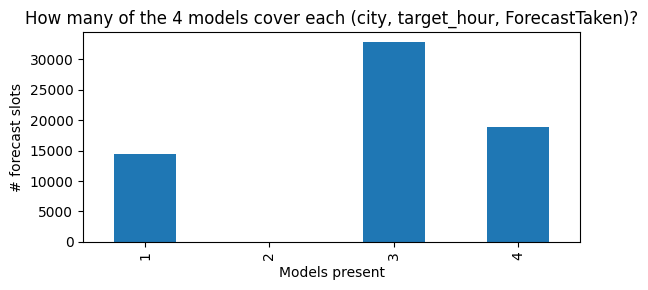

In [56]:
# Diagnostic 2: coverage histogram — for each unique (city, Date, Time, ForecastTaken),
# how many of the 4 models have a row? Tells us whether outer-join keeps clean "3+ model"
# rows (acceptable) or mostly noisy "1-2 model" rows (less useful).

models_per_slot = (raw_h
                   .groupby(['city', 'Date', 'Time', 'ForecastTaken'])['Model']
                   .nunique()
                   .rename('n_models'))

print('Number of forecast slots by how many models cover them:')
counts = models_per_slot.value_counts().sort_index()
print(counts)
print(f'\nTotal unique slots: {len(models_per_slot):,}')
print(f'4-model slots: {counts.get(4, 0):,} ({counts.get(4, 0) / len(models_per_slot):.1%})')
print(f'3+ model slots: {counts.loc[3:].sum():,} ({counts.loc[3:].sum() / len(models_per_slot):.1%})')

fig, ax = plt.subplots(figsize=(6, 3))
counts.plot(kind='bar', ax=ax)
ax.set_xlabel('Models present')
ax.set_ylabel('# forecast slots')
ax.set_title('How many of the 4 models cover each (city, target_hour, ForecastTaken)?')
plt.tight_layout()
plt.show()

In [57]:
# Diagnostic 3: OpenMeteo time alignment check.
# For a fixed (city, ForecastTaken) cohort, look at the set of hours_ahead values each
# model issues. If OpenMeteo systematically targets a shifted set of hours vs MetOffice,
# the inner-join silently drops rows even when both models have data.

# Pick the most recent ForecastTaken in each city, then check overlap of hours_ahead per model.
sample = raw_h.copy()
sample['ForecastTaken'] = pd.to_datetime(sample['ForecastTaken'])
latest_ft = sample.groupby('city')['ForecastTaken'].max().to_dict()
sample = sample[sample.apply(lambda r: r['ForecastTaken'] == latest_ft[r['city']], axis=1)]

per_model_hours = (sample
                   .groupby(['city', 'Model'])['hours_ahead']
                   .agg(['min', 'max', 'count'])
                   .reset_index())
print('hours_ahead range per model for each city\'s most recent ForecastTaken:')
print(per_model_hours.pivot(index='city', columns='Model', values='count').fillna(0).astype(int))

# Now check overlap — for each (city, ForecastTaken) in sample, are MetOffice and OpenMeteo-ECMWF
# targeting the same hours_ahead set?
def overlap_check(group):
    by_model = {m: set(group.loc[group['Model'] == m, 'hours_ahead'].astype(int))
                for m in MODELS}
    return pd.Series({
        f'{m}_n': len(by_model[m]) for m in MODELS
    } | {
        'MO_vs_ECMWF_overlap': len(by_model['MetOffice'] & by_model['OpenMeteo-ECMWF']),
        'MO_vs_GFS_overlap':   len(by_model['MetOffice'] & by_model['OpenMeteo-GFSHRRR']),
        'ECMWF_vs_GFS_overlap': len(by_model['OpenMeteo-ECMWF'] & by_model['OpenMeteo-GFSHRRR']),
    })

overlap_df = sample.groupby(['city', 'ForecastTaken']).apply(overlap_check, include_groups=False)
print('\nHours-ahead overlap between MetOffice / OpenMeteo variants per city (latest ForecastTaken):')
print(overlap_df)

hours_ahead range per model for each city's most recent ForecastTaken:
Model       AccuWeather  MetOffice  OpenMeteo-ECMWF  OpenMeteo-GFSHRRR
city                                                                  
Aberdeen              1          2                2                  2
Birmingham            1          2                2                  2
Bristol               1          2                2                  2
Cardiff               1          2                2                  2
Glasgow               1          2                2                  2
Leeds                 1          2                2                  2
London                1          1                1                  1
Manchester            0          0                1                  0
Newcastle             1          2                2                  2
Norwich               1          2                2                  2
Penzance              1          2                2                  2

Hours

In [58]:
# Diagnostic 4: complete-universe size for the strict 4-model short-horizon view.
# Compare against the raw row count to see how much survives if we filter to hours_ahead<=12
# AND require all 4 models present. This is the upper bound for short-horizon AccuWeather analysis.

raw_short = raw_h[raw_h['hours_ahead'] <= 12]
slots_short = (raw_short
               .groupby(['city', 'Date', 'Time', 'ForecastTaken'])['Model']
               .nunique())

print(f'Raw rows (any horizon):                       {len(raw_h):,}')
print(f'Raw rows (hours_ahead <= 12):                 {len(raw_short):,}')
print(f'Unique slots (hours_ahead <= 12):             {len(slots_short):,}')
print(f'Unique slots with all 4 models present:       {(slots_short == 4).sum():,}')
print(f'Unique slots with 3+ models present:          {(slots_short >= 3).sum():,}')
print(f'pivoted_h_strict (already computed):           {len(pivoted_h_strict):,} rows')

Raw rows (any horizon):                       190,960
Raw rows (hours_ahead <= 12):                 75,378
Unique slots (hours_ahead <= 12):             18,993
Unique slots with all 4 models present:       17,498
Unique slots with 3+ models present:          18,958
pivoted_h_strict (already computed):           17,483 rows


## 2. Forecast-evolution features

For each (city, Model, target_datetime), look back across the previous 24 issues (ForecastTaken values) and compute stddev, range, and trend of the model's prediction. Captures forecast confidence and drift.

Computed in SQL with window functions because the cardinality is large. Once retention is at 365 days the indexes from `db_migrate.py` make this fast.

In [59]:
EVOLUTION_SQL = """
SELECT
  city,
  "Model",
  "Date", "Time", "ForecastTaken",
  STDDEV("Temperature") OVER w24      AS temp_stddev_24,
  MAX("Temperature")    OVER w24
    - MIN("Temperature") OVER w24     AS temp_range_24,
  "Temperature" - LAG("Temperature", 12) OVER w_ordered AS temp_trend_12,
  STDDEV("WindSpeed") OVER w24        AS wind_stddev_24,
  MAX("WindSpeed") OVER w24
    - MIN("WindSpeed") OVER w24       AS wind_range_24,
  "WindSpeed" - LAG("WindSpeed", 12) OVER w_ordered      AS wind_trend_12,
  STDDEV("RainProbability") OVER w24  AS rainprob_stddev_24,
  "RainProbability" - LAG("RainProbability", 12) OVER w_ordered AS rainprob_trend_12
FROM hourly_forecast
WINDOW
  w_ordered AS (PARTITION BY city, "Model", "Date", "Time" ORDER BY "ForecastTaken"),
  w24       AS (PARTITION BY city, "Model", "Date", "Time" ORDER BY "ForecastTaken"
                ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING)
"""

EVO_VARS = ['temp_stddev_24', 'temp_range_24', 'temp_trend_12',
            'wind_stddev_24', 'wind_range_24', 'wind_trend_12',
            'rainprob_stddev_24', 'rainprob_trend_12']


def fetch_evolution_hourly(engine, models_to_include=None):
    """Run the window query and pivot models -> columns. Returns one row per (city, target, ForecastTaken)."""
    evo_raw = pd.read_sql(EVOLUTION_SQL, engine)
    if models_to_include is not None:
        evo_raw = evo_raw[evo_raw['Model'].isin(models_to_include)]
    evo_pivot = (evo_raw.pivot_table(
        index=['city', 'Date', 'Time', 'ForecastTaken'],
        columns='Model',
        values=EVO_VARS,
        aggfunc='first',
    ).reset_index())
    return _flatten_pivot_cols(evo_pivot)


evo_pivot_h = fetch_evolution_hourly(engine)
print(f'evolution pivot rows: {len(evo_pivot_h):,}, cols: {len(evo_pivot_h.columns)}')
print(f'evolution feature coverage: {evo_pivot_h.notna().mean().mean():.1%}')
evo_pivot_h.head()

evolution pivot rows: 101,209, cols: 36
evolution feature coverage: 60.8%


,city,Date,Time,ForecastTaken,AccuWeather_rainprob_stddev_24,MetOffice_rainprob_stddev_24,OpenMeteo-ECMWF_rainprob_stddev_24,OpenMeteo-GFSHRRR_rainprob_stddev_24,AccuWeather_rainprob_trend_12,MetOffice_rainprob_trend_12,...,OpenMeteo-ECMWF_wind_range_24,OpenMeteo-GFSHRRR_wind_range_24,AccuWeather_wind_stddev_24,MetOffice_wind_stddev_24,OpenMeteo-ECMWF_wind_stddev_24,OpenMeteo-GFSHRRR_wind_stddev_24,AccuWeather_wind_trend_12,MetOffice_wind_trend_12,OpenMeteo-ECMWF_wind_trend_12,OpenMeteo-GFSHRRR_wind_trend_12
0,Aberdeen,2026-05-19,00:00:00,2026-05-19 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aberdeen,2026-05-19,00:00:00,2026-05-19 21:00:00,NaN,NaN,0.0,0.0,NaN,NaN,...,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,Aberdeen,2026-05-19,00:00:00,2026-05-19 22:00:00,NaN,NaN,0.0,0.0,NaN,NaN,...,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,Aberdeen,2026-05-19,01:00:00,2026-05-19 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Aberdeen,2026-05-19,01:00:00,2026-05-19 21:00:00,NaN,NaN,0.0,0.0,NaN,NaN,...,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


## 3. Lag observation features

For each row, look up the city's observed temp / wind / rainfall at `ForecastTaken − 1h`, `−3h`, `−6h`. Critical: these are obs known *at the moment the forecast was made*, not at the target time.

In [60]:
# Load observations once, dedupe on (city, hour), reuse across all tiers/targets.
obs_all = load_observations(engine)

pivoted_h_short = add_lag_features(pivoted_h_short, obs_all, hours_list=(1, 3, 6))

print('Hourly-Short lag coverage:')
print(pivoted_h_short[[f'lag{h}h_temp' for h in (1, 3, 6)]].notna().mean())

Hourly-Short lag coverage:
lag1h_temp    0.982613
lag3h_temp    0.947781
lag6h_temp    0.942976
dtype: float64


## 4. Time, location, and direction features

Cyclical encoding for hour-of-day and day-of-year; one-hot for city; sin/cos for wind direction.

In [61]:
pivoted_h_short = add_time_features(pivoted_h_short)
pivoted_h_short = add_winddir_features(pivoted_h_short, MODELS)
pivoted_h_short = add_city_features(pivoted_h_short)
print(f'Hourly-Short feature columns: {len(pivoted_h_short.columns)}')

Hourly-Short feature columns: 63


## 5. Merge evolution features into training matrix

In [62]:
training_short = merge_evolution(pivoted_h_short, evo_pivot_h)
print(f'Hourly-Short training rows: {len(training_short):,}, cols: {len(training_short.columns)}')
training_short.head(2)

Hourly-Short training rows: 17,484, cols: 95


,city,Date,Time,ForecastTaken,hours_ahead,obs_temperature,obs_windspeed_kmh,obs_winddir,obs_maxrainfall,AccuWeather_fc_rainprob,...,OpenMeteo-ECMWF_wind_range_24,OpenMeteo-GFSHRRR_wind_range_24,AccuWeather_wind_stddev_24,MetOffice_wind_stddev_24,OpenMeteo-ECMWF_wind_stddev_24,OpenMeteo-GFSHRRR_wind_stddev_24,AccuWeather_wind_trend_12,MetOffice_wind_trend_12,OpenMeteo-ECMWF_wind_trend_12,OpenMeteo-GFSHRRR_wind_trend_12
0,Aberdeen,2026-05-19,21:00:00,2026-05-19 19:00:00,2.0,10.81,5.310835,157.5,1.2,61.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aberdeen,2026-05-20,01:00:00,2026-05-19 19:00:00,6.0,10.37,8.207654,180.0,0.6,41.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Time-based train/test split

Older 80% by `ForecastTaken` to train, newest 20% to test. Mimics production use (predict the future from the past).

In [63]:
train_short, test_short, cutoff_short = time_split(training_short, test_frac=0.2)
print(f'Hourly-Short  train: {len(train_short):,} | test: {len(test_short):,} | cutoff: {cutoff_short}')

Hourly-Short  train: 13,961 | test: 3,523 | cutoff: 2026-05-25 02:00:00


## 7. Define feature columns

In [64]:
feature_cols_short = feature_columns(training_short, MODELS)
print(f'Hourly-Short: {len(feature_cols_short)} features')

Hourly-Short: 81 features


## 8. Train and evaluate — Temperature

Ridge, RandomForest, LightGBM, all on the same features. Baseline comparison against each of the 4 source models on the same test rows.

In [65]:
# Registry that every train_tier call appends to. Used by the cross-tier summary later.
all_results = []


def record(pipeline, target, models_dict):
    """Append a training result into the global all_results registry."""
    for k, v in models_dict['metrics'].items():
        all_results.append({'pipeline': pipeline, 'target': target,
                            'model': k, 'mae': v, 'n_test': models_dict['n_test']})


temp_short = train_tier(
    train_short, test_short,
    target_col='obs_temperature',
    feature_cols=feature_cols_short,
    source_fc_cols=[f'{m}_fc_temperature' for m in MODELS],
    label='Hourly-Short Temperature',
)
record('Hourly-Short', 'Temperature', temp_short)


=== Hourly-Short Temperature — MAE on test set (3523 rows) ===
  LightGBM                            1.151
  Ridge                               1.328
  RandomForest                        1.337
  OpenMeteo-ECMWF_fc_temperature      1.477
  OpenMeteo-GFSHRRR_fc_temperature    1.624
  MetOffice_fc_temperature            2.111
  AccuWeather_fc_temperature          2.493


## 9. Train and evaluate — WindSpeed

In [66]:
wind_short = train_tier(
    train_short, test_short,
    target_col='obs_windspeed_kmh',
    feature_cols=feature_cols_short,
    source_fc_cols=[f'{m}_fc_windspeed_kmh' for m in MODELS],
    label='Hourly-Short WindSpeed',
)
record('Hourly-Short', 'WindSpeed', wind_short)


=== Hourly-Short WindSpeed — MAE on test set (3523 rows) ===
  LightGBM                            1.137
  RandomForest                        1.222
  Ridge                               1.399
  MetOffice_fc_windspeed_kmh          1.870
  OpenMeteo-ECMWF_fc_windspeed_kmh    3.791
  OpenMeteo-GFSHRRR_fc_windspeed_kmh  4.716
  AccuWeather_fc_windspeed_kmh        6.083


## 10. MAE bucketed by forecast horizon

Does the ensemble beat the source models *at every horizon*, or only on average? Big horizons are where the easy wins live.

In [67]:
def horizon_table(models, test_df, target_col, feature_cols, source_fc_cols,
                   buckets_def=([0, 6, 12, 24, 48, np.inf],
                                ['1-6h', '7-12h', '13-24h', '25-48h', '49h+'])):
    """MAE per horizon bucket for ensemble models + source models on same test slice."""
    X_te = test_df[feature_cols].fillna(0)
    y_te = test_df[target_col]
    preds = {
        'Ridge':        models['ridge'].predict(X_te),
        'RandomForest': models['rf'].predict(X_te),
    }
    if models['lgbm'] is not None:
        preds['LightGBM'] = models['lgbm'].predict(X_te)
    for fc in source_fc_cols:
        if fc in test_df.columns:
            preds[fc] = test_df[fc].values

    edges, labels = buckets_def
    buckets = pd.cut(test_df['hours_ahead'], bins=edges, labels=labels)
    rows = []
    for label, pred in preds.items():
        for b in buckets.cat.categories:
            mask = (buckets == b) & y_te.notna() & pd.Series(pred).notna()
            if mask.sum() > 0:
                rows.append({'model': label, 'horizon': b,
                             'mae': mean_absolute_error(y_te[mask], pred[mask]),
                             'n': mask.sum()})
    return pd.DataFrame(rows).pivot(index='model', columns='horizon', values='mae')


print('Hourly-Short Temperature MAE by horizon')
print(horizon_table(temp_short, test_short, 'obs_temperature', feature_cols_short,
                    [f'{m}_fc_temperature' for m in MODELS]).round(3))
print('\nHourly-Short WindSpeed MAE by horizon')
print(horizon_table(wind_short, test_short, 'obs_windspeed_kmh', feature_cols_short,
                    [f'{m}_fc_windspeed_kmh' for m in MODELS]).round(3))

Hourly-Short Temperature MAE by horizon
horizon                            1-6h  7-12h
model                                         
AccuWeather_fc_temperature        2.747  2.243
LightGBM                          1.108  1.193
MetOffice_fc_temperature          2.231  1.993
OpenMeteo-ECMWF_fc_temperature    1.476  1.478
OpenMeteo-GFSHRRR_fc_temperature  1.597  1.650
RandomForest                      1.283  1.389
Ridge                             1.299  1.418

Hourly-Short WindSpeed MAE by horizon
horizon                              1-6h  7-12h
model                                           
AccuWeather_fc_windspeed_kmh        6.063  6.102
LightGBM                            1.107  1.167
MetOffice_fc_windspeed_kmh          1.963  1.777
OpenMeteo-ECMWF_fc_windspeed_kmh    3.813  3.768
OpenMeteo-GFSHRRR_fc_windspeed_kmh  4.790  4.642
RandomForest                        1.165  1.279
Ridge                               1.366  1.457


## 11. Feature importance

Which features does LightGBM lean on? If the forecast-evolution features rank high, the 1-year retention investment paid off.

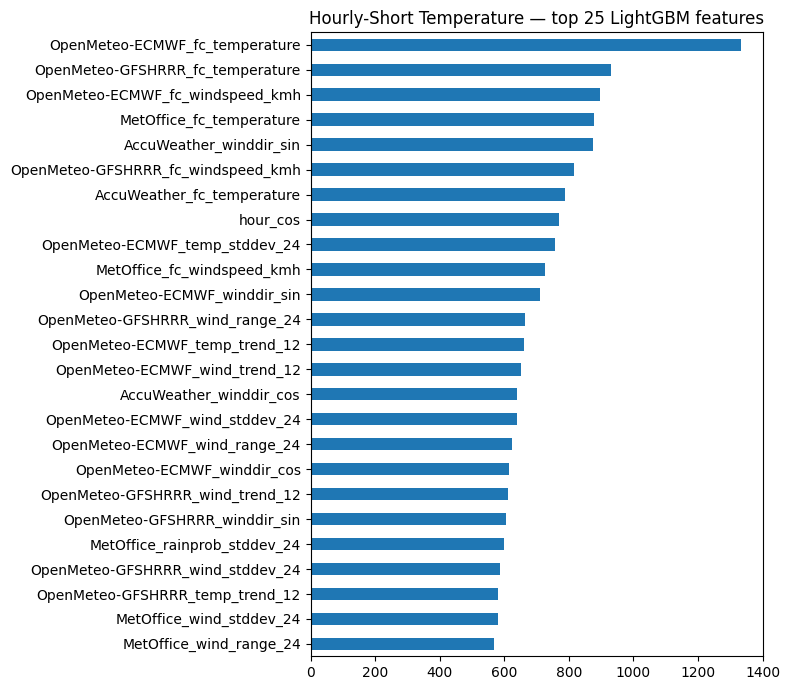

In [68]:
def plot_top_features(tier_models, feature_cols, title, top_n=25):
    if tier_models['lgbm'] is None:
        print('LightGBM not available — skipping importance plot')
        return
    imp = pd.Series(tier_models['lgbm'].feature_importances_, index=feature_cols)
    imp = imp.sort_values(ascending=True).tail(top_n)
    fig, ax = plt.subplots(figsize=(8, 7))
    imp.plot(kind='barh', ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


plot_top_features(temp_short, feature_cols_short,
                  'Hourly-Short Temperature — top 25 LightGBM features')

## 12. Hourly-Long pipeline (13-48h, 3 models)

Drops AccuWeather entirely. MetOffice is required (100% coverage); OpenMeteo-ECMWF and OpenMeteo-GFSHRRR are outer-joined — OpenMeteo will be NaN for roughly half of the 25-48h rows. LightGBM handles the NaN natively; Ridge and RandomForest get mean-imputation.

In [69]:
MODELS_LONG = ['MetOffice', 'OpenMeteo-ECMWF', 'OpenMeteo-GFSHRRR']

pivoted_h_long = build_pivot(
    raw_h,
    models_to_pivot=MODELS_LONG,
    require_models=['MetOffice'],   # MetOffice always covers 13-48h; OpenMeteo may be NaN
    hours_filter=(13, 48),
)
print(f'pivoted_h_long rows: {len(pivoted_h_long):,}')

# Feature pipeline (reuses Short helpers, scoped to MODELS_LONG)
pivoted_h_long = add_lag_features(pivoted_h_long, obs_all, hours_list=(1, 3, 6))
pivoted_h_long = add_time_features(pivoted_h_long)
pivoted_h_long = add_winddir_features(pivoted_h_long, MODELS_LONG)
pivoted_h_long = add_city_features(pivoted_h_long)
pivoted_h_long = add_presence_indicators(pivoted_h_long, MODELS_LONG)

training_long = merge_evolution(pivoted_h_long, evo_pivot_h)
print(f'training_long rows: {len(training_long):,}, cols: {len(training_long.columns)}')

# Sanity-check OpenMeteo NaN rate
om_nan = training_long['OpenMeteo-ECMWF_fc_temperature'].isna().mean()
print(f'OpenMeteo-ECMWF NaN rate across full Long matrix: {om_nan:.1%}')
print('NaN rate within 25-48h slice:',
      f"{training_long.loc[training_long['hours_ahead'] >= 25, 'OpenMeteo-ECMWF_fc_temperature'].isna().mean():.1%}")

pivoted_h_long rows: 47,052
training_long rows: 47,052, cols: 91
OpenMeteo-ECMWF NaN rate across full Long matrix: 30.4%
NaN rate within 25-48h slice: 48.6%


In [70]:
train_long, test_long, cutoff_long = time_split(training_long, test_frac=0.2)
print(f'Hourly-Long  train: {len(train_long):,} | test: {len(test_long):,} | cutoff: {cutoff_long}')

feature_cols_long = feature_columns(training_long, MODELS_LONG)
print(f'Hourly-Long: {len(feature_cols_long)} features')

temp_long = train_tier(
    train_long, test_long,
    target_col='obs_temperature',
    feature_cols=feature_cols_long,
    source_fc_cols=[f'{m}_fc_temperature' for m in MODELS_LONG],
    label='Hourly-Long Temperature',
)
record('Hourly-Long', 'Temperature', temp_long)

wind_long = train_tier(
    train_long, test_long,
    target_col='obs_windspeed_kmh',
    feature_cols=feature_cols_long,
    source_fc_cols=[f'{m}_fc_windspeed_kmh' for m in MODELS_LONG],
    label='Hourly-Long WindSpeed',
)
record('Hourly-Long', 'WindSpeed', wind_long)

Hourly-Long  train: 37,581 | test: 9,471 | cutoff: 2026-05-24 08:00:00
Hourly-Long: 78 features

=== Hourly-Long Temperature — MAE on test set (9471 rows) ===
  LightGBM                            0.791
  RandomForest                        0.860
  OpenMeteo-ECMWF_fc_temperature      1.531
  Ridge                               1.556
  OpenMeteo-GFSHRRR_fc_temperature    1.739
  MetOffice_fc_temperature            1.898

=== Hourly-Long WindSpeed — MAE on test set (9471 rows) ===
  LightGBM                            1.044
  RandomForest                        1.139
  Ridge                               1.533
  MetOffice_fc_windspeed_kmh          1.735
  OpenMeteo-ECMWF_fc_windspeed_kmh    3.726
  OpenMeteo-GFSHRRR_fc_windspeed_kmh  4.500


In [71]:
print('Hourly-Long Temperature MAE by horizon')
print(horizon_table(temp_long, test_long, 'obs_temperature', feature_cols_long,
                    [f'{m}_fc_temperature' for m in MODELS_LONG]).round(3))
print('\nHourly-Long WindSpeed MAE by horizon')
print(horizon_table(wind_long, test_long, 'obs_windspeed_kmh', feature_cols_long,
                    [f'{m}_fc_windspeed_kmh' for m in MODELS_LONG]).round(3))

Hourly-Long Temperature MAE by horizon
horizon                           13-24h  25-48h
model                                           
LightGBM                           0.721   1.240
MetOffice_fc_temperature           1.896   1.899
OpenMeteo-ECMWF_fc_temperature     1.547   1.500
OpenMeteo-GFSHRRR_fc_temperature   1.733   1.750
RandomForest                       0.780   1.050
Ridge                              1.487   1.622

Hourly-Long WindSpeed MAE by horizon
horizon                             13-24h  25-48h
model                                             
LightGBM                             0.970   1.282
MetOffice_fc_windspeed_kmh           1.749   1.721
OpenMeteo-ECMWF_fc_windspeed_kmh     3.717   3.743
OpenMeteo-GFSHRRR_fc_windspeed_kmh   4.557   4.393
RandomForest                         1.056   1.259
Ridge                                1.479   1.578


## 13. Remaining hourly targets: RainProbability, RainVolume, WindDirection

RainProbability target = `(obs_maxrainfall > 0) * 100` (binary outcome treated as a 0/100 regression — Ridge produces a calibrated probability, LightGBM produces a smooth score). RainVolume target = `obs_maxrainfall` directly. WindDirection is trained as two separate regressions on (sin, cos) and evaluated via circular MAE in degrees.

In [72]:
def add_rain_targets(df):
    """obs_rainprob (binary 0/100), obs_rainvol (raw)."""
    df['obs_rainprob'] = (df['obs_maxrainfall'] > 0).astype(float) * 100
    df['obs_rainvol'] = df['obs_maxrainfall']
    return df


def circular_mae(true_deg, pred_deg):
    """Mean absolute error on angles in degrees, with wrap-around (max error is 180)."""
    true_deg = np.asarray(true_deg)
    pred_deg = np.asarray(pred_deg)
    diff = ((pred_deg - true_deg + 180) % 360) - 180
    return float(np.mean(np.abs(diff)))


def evaluate_winddir(sin_models, cos_models, train, test, feature_cols, source_fc_cols, label):
    """Combine sin/cos predictions, report circular MAE in degrees vs source winddir columns."""
    train_means = train[feature_cols].mean().fillna(0)
    X_te = test[feature_cols]
    X_te_imp = X_te.fillna(train_means)
    y_te_deg = test['obs_winddir']
    mask = y_te_deg.notna()

    results = {}
    for fc in source_fc_cols:
        if fc in test.columns:
            m = mask & test[fc].notna()
            if m.sum() > 0:
                results[fc] = circular_mae(test.loc[m, 'obs_winddir'], test.loc[m, fc])

    for est_name, attr in [('Ridge', 'ridge'), ('RandomForest', 'rf'), ('LightGBM', 'lgbm')]:
        if sin_models[attr] is None or cos_models[attr] is None:
            continue
        X = X_te if attr == 'lgbm' else X_te_imp
        sin_p = sin_models[attr].predict(X)
        cos_p = cos_models[attr].predict(X)
        angle = np.rad2deg(np.arctan2(sin_p, cos_p)) % 360
        results[est_name] = circular_mae(y_te_deg[mask], angle[mask])

    print(f'\n=== {label} — Circular MAE (degrees) ===')
    for k, v in sorted(results.items(), key=lambda kv: kv[1]):
        print(f'  {k:35s} {v:.2f}')
    return {'metrics': results, 'n_test': int(mask.sum())}


# Add rain targets to both training matrices, then re-split (cheap; reuses cutoff implicitly).
training_short = add_rain_targets(training_short)
training_long  = add_rain_targets(training_long)
train_short, test_short, cutoff_short = time_split(training_short, test_frac=0.2)
train_long,  test_long,  cutoff_long  = time_split(training_long,  test_frac=0.2)
print('rain targets added; train/test resplit done')

rain targets added; train/test resplit done


In [73]:
# Hourly-Short: RainProbability, RainVolume, WindDirection (sin/cos)

rainprob_short = train_tier(
    train_short, test_short,
    target_col='obs_rainprob',
    feature_cols=feature_cols_short,
    source_fc_cols=[f'{m}_fc_rainprob' for m in MODELS],
    label='Hourly-Short RainProbability',
)
record('Hourly-Short', 'RainProbability', rainprob_short)

rainvol_short = train_tier(
    train_short, test_short,
    target_col='obs_rainvol',
    feature_cols=feature_cols_short,
    source_fc_cols=[f'{m}_fc_rainvol' for m in MODELS],
    label='Hourly-Short RainVolume',
)
record('Hourly-Short', 'RainVolume', rainvol_short)

# WindDirection: separate sin and cos regressions, then circular MAE
winddir_sin_short = train_tier(
    train_short, test_short,
    target_col='obs_winddir_sin',
    feature_cols=feature_cols_short,
    source_fc_cols=[],
    label='Hourly-Short WindDirection (sin component)',
)
winddir_cos_short = train_tier(
    train_short, test_short,
    target_col='obs_winddir_cos',
    feature_cols=feature_cols_short,
    source_fc_cols=[],
    label='Hourly-Short WindDirection (cos component)',
)
winddir_short = evaluate_winddir(
    winddir_sin_short, winddir_cos_short,
    train_short, test_short,
    feature_cols_short,
    [f'{m}_fc_winddir' for m in MODELS],
    'Hourly-Short WindDirection',
)
record('Hourly-Short', 'WindDirection', winddir_short)


=== Hourly-Short RainProbability — MAE on test set (3523 rows) ===
  OpenMeteo-ECMWF_fc_rainprob         5.729
  MetOffice_fc_rainprob               5.858
  AccuWeather_fc_rainprob             6.149
  OpenMeteo-GFSHRRR_fc_rainprob       6.689
  RandomForest                        10.629
  LightGBM                            10.898
  Ridge                               15.252

=== Hourly-Short RainVolume — MAE on test set (3523 rows) ===
  OpenMeteo-GFSHRRR_fc_rainvol        0.001
  OpenMeteo-ECMWF_fc_rainvol          0.003
  AccuWeather_fc_rainvol              0.005
  MetOffice_fc_rainvol                0.006
  LightGBM                            0.013
  RandomForest                        0.019
  Ridge                               0.053

=== Hourly-Short WindDirection (sin component) — MAE on test set (3523 rows) ===
  LightGBM                            0.293
  Ridge                               0.328
  RandomForest                        0.332

=== Hourly-Short WindDirection (cos

In [74]:
# Hourly-Long: RainProbability, RainVolume, WindDirection (sin/cos)

rainprob_long = train_tier(
    train_long, test_long,
    target_col='obs_rainprob',
    feature_cols=feature_cols_long,
    source_fc_cols=[f'{m}_fc_rainprob' for m in MODELS_LONG],
    label='Hourly-Long RainProbability',
)
record('Hourly-Long', 'RainProbability', rainprob_long)

rainvol_long = train_tier(
    train_long, test_long,
    target_col='obs_rainvol',
    feature_cols=feature_cols_long,
    source_fc_cols=[f'{m}_fc_rainvol' for m in MODELS_LONG],
    label='Hourly-Long RainVolume',
)
record('Hourly-Long', 'RainVolume', rainvol_long)

winddir_sin_long = train_tier(
    train_long, test_long,
    target_col='obs_winddir_sin',
    feature_cols=feature_cols_long,
    source_fc_cols=[],
    label='Hourly-Long WindDirection (sin component)',
)
winddir_cos_long = train_tier(
    train_long, test_long,
    target_col='obs_winddir_cos',
    feature_cols=feature_cols_long,
    source_fc_cols=[],
    label='Hourly-Long WindDirection (cos component)',
)
winddir_long = evaluate_winddir(
    winddir_sin_long, winddir_cos_long,
    train_long, test_long,
    feature_cols_long,
    [f'{m}_fc_winddir' for m in MODELS_LONG],
    'Hourly-Long WindDirection',
)
record('Hourly-Long', 'WindDirection', winddir_long)


=== Hourly-Long RainProbability — MAE on test set (9471 rows) ===
  RandomForest                        3.845
  LightGBM                            6.705
  OpenMeteo-ECMWF_fc_rainprob         6.770
  MetOffice_fc_rainprob               6.786
  OpenMeteo-GFSHRRR_fc_rainprob       8.236
  Ridge                               15.004

=== Hourly-Long RainVolume — MAE on test set (9471 rows) ===
  OpenMeteo-GFSHRRR_fc_rainvol        0.001
  OpenMeteo-ECMWF_fc_rainvol          0.005
  MetOffice_fc_rainvol                0.007
  LightGBM                            0.010
  RandomForest                        0.011
  Ridge                               0.043

=== Hourly-Long WindDirection (sin component) — MAE on test set (9471 rows) ===
  LightGBM                            0.268
  RandomForest                        0.275
  Ridge                               0.347

=== Hourly-Long WindDirection (cos component) — MAE on test set (9471 rows) ===
  LightGBM                            0.281
  Ra

## 14. Daily pipeline

Parallel ensemble over `daily_forecast` joined to a per-day aggregation of `observations`. All 4 daily APIs have different horizons (AccuWeather 5d, MetOffice 7d, OpenMeteo 14d), so we use outer-join + NaN handling instead of splitting into tiers.

Targets: MinTemperature, MaxTemperature, WindSpeed, RainProbability, RainVolume. WindDirection for daily needs vector-aggregation across hourly observations — deferred to a later iteration.

In [75]:
DAILY_JOIN_SQL = """
WITH daily_obs AS (
  SELECT city, "Date",
         MIN("Temperature")        AS obs_mintemp,
         MAX("Temperature")        AS obs_maxtemp,
         AVG("WindSpeed") * %(mph_to_kmh)s AS obs_windspeed_avg,
         MAX("MaxRainfall")        AS obs_rain_any,
         SUM("MaxRainfall")        AS obs_rain_total
  FROM observations
  GROUP BY city, "Date"
)
SELECT
  df.city, df."Date", df."Model", df."ForecastTaken",
  (df."Date" - df."ForecastTaken"::date) AS days_ahead,
  df."MinTemperature" AS fc_mintemp,
  df."MaxTemperature" AS fc_maxtemp,
  CASE WHEN df."Model" = 'MetOffice' THEN df."WindSpeed" * %(mph_to_kmh)s
       ELSE df."WindSpeed" END AS fc_windspeed_kmh,
  df."WindDirection"  AS fc_winddir,
  df."RainProbability" AS fc_rainprob,
  df."RainVolume"     AS fc_rainvol,
  d_obs.obs_mintemp, d_obs.obs_maxtemp, d_obs.obs_windspeed_avg,
  d_obs.obs_rain_any, d_obs.obs_rain_total
FROM daily_forecast df
JOIN daily_obs d_obs ON df.city = d_obs.city AND df."Date" = d_obs."Date"
WHERE (df."Date" - df."ForecastTaken"::date) > 0
"""

raw_d = pd.read_sql(DAILY_JOIN_SQL, engine, params={'mph_to_kmh': MPH_TO_KMH})
print(f'raw daily rows: {len(raw_d):,}')

# Per-model coverage by days_ahead bucket — confirms 4-cliff structure (AW 5d, MO 7d, OM 14d).
print('\nDaily coverage by model and days_ahead:')
print(raw_d.groupby(['days_ahead', 'Model']).size().unstack(fill_value=0))

raw daily rows: 133,854

Daily coverage by model and days_ahead:
Model       AccuWeather  MetOffice  OpenMeteo-ECMWF  OpenMeteo-GFSHRRR
days_ahead                                                            
1                  5026       5013             5019               5015
2                  4765       4752             4758               4754
3                  4502       4489             4495               4491
4                  3686       4230             4235               4232
5                     0       3994             3999               3996
6                     0       2625             3737               3734
7                     0          0             3499               3496
8                     0          0             3256               3254
9                     0          0             2999               2997
10                    0          0             2739               2737
11                    0          0             2479               2477
12          

In [76]:
DAILY_INDEX_COLS = ['city', 'Date', 'ForecastTaken', 'days_ahead',
                    'obs_mintemp', 'obs_maxtemp', 'obs_windspeed_avg',
                    'obs_rain_any', 'obs_rain_total']
DAILY_VALUE_COLS = ['fc_mintemp', 'fc_maxtemp', 'fc_windspeed_kmh',
                    'fc_winddir', 'fc_rainprob', 'fc_rainvol']

# Daily uses outer-join: require MetOffice (broadest non-OpenMeteo coverage), allow others NaN.
pivoted_d = build_pivot(
    raw_d,
    models_to_pivot=MODELS,
    require_models=['MetOffice'],
    hours_filter=None,
    index_cols=DAILY_INDEX_COLS,
    value_cols=DAILY_VALUE_COLS,
)
print(f'pivoted_d rows: {len(pivoted_d):,}')

# Daily-specific rain targets
pivoted_d['obs_rainprob'] = (pivoted_d['obs_rain_any'] > 0).astype(float) * 100
pivoted_d['obs_rainvol'] = pivoted_d['obs_rain_total']

# Feature pipeline: time uses Date only (no Time column), lag = observation N days back
pivoted_d = add_time_features(pivoted_d, date_col='Date', time_col='__none__')  # skips hour branch
pivoted_d = add_winddir_features(pivoted_d, MODELS)
pivoted_d = add_city_features(pivoted_d)
pivoted_d = add_presence_indicators(pivoted_d, MODELS, ref_col='fc_mintemp')
pivoted_d = add_lag_features(pivoted_d, obs_all, hours_list=(24, 48, 72), unit='hours')

print(f'pivoted_d cols after features: {len(pivoted_d.columns)}')
print('Per-model NaN rate:', {m: f"{pivoted_d[f'{m}_fc_mintemp'].isna().mean():.1%}" for m in MODELS})

pivoted_d rows: 25,103
pivoted_d cols after features: 69
Per-model NaN rate: {'MetOffice': '0.0%', 'OpenMeteo-ECMWF': '0.0%', 'OpenMeteo-GFSHRRR': '0.0%', 'AccuWeather': '28.6%'}


In [77]:
train_daily, test_daily, cutoff_daily = time_split(pivoted_d, test_frac=0.2)
print(f'Daily  train: {len(train_daily):,} | test: {len(test_daily):,} | cutoff: {cutoff_daily}')

feature_cols_d = feature_columns(pivoted_d, MODELS)
print(f'Daily: {len(feature_cols_d)} features')

Daily  train: 20,082 | test: 5,021 | cutoff: 2026-05-20 05:00:00
Daily: 55 features


In [78]:
mintemp_d = train_tier(
    train_daily, test_daily,
    target_col='obs_mintemp',
    feature_cols=feature_cols_d,
    source_fc_cols=[f'{m}_fc_mintemp' for m in MODELS],
    label='Daily MinTemperature',
)
record('Daily', 'MinTemperature', mintemp_d)

maxtemp_d = train_tier(
    train_daily, test_daily,
    target_col='obs_maxtemp',
    feature_cols=feature_cols_d,
    source_fc_cols=[f'{m}_fc_maxtemp' for m in MODELS],
    label='Daily MaxTemperature',
)
record('Daily', 'MaxTemperature', maxtemp_d)

wind_d = train_tier(
    train_daily, test_daily,
    target_col='obs_windspeed_avg',
    feature_cols=feature_cols_d,
    source_fc_cols=[f'{m}_fc_windspeed_kmh' for m in MODELS],
    label='Daily WindSpeed (mean)',
)
record('Daily', 'WindSpeed', wind_d)

rainprob_d = train_tier(
    train_daily, test_daily,
    target_col='obs_rainprob',
    feature_cols=feature_cols_d,
    source_fc_cols=[f'{m}_fc_rainprob' for m in MODELS],
    label='Daily RainProbability',
)
record('Daily', 'RainProbability', rainprob_d)

rainvol_d = train_tier(
    train_daily, test_daily,
    target_col='obs_rainvol',
    feature_cols=feature_cols_d,
    source_fc_cols=[f'{m}_fc_rainvol' for m in MODELS],
    label='Daily RainVolume',
)
record('Daily', 'RainVolume', rainvol_d)


=== Daily MinTemperature — MAE on test set (5021 rows) ===
  LightGBM                            1.212
  RandomForest                        1.375
  OpenMeteo-ECMWF_fc_mintemp          1.863
  Ridge                               1.960
  OpenMeteo-GFSHRRR_fc_mintemp        2.112
  AccuWeather_fc_mintemp              2.527
  MetOffice_fc_mintemp                2.827

=== Daily MaxTemperature — MAE on test set (5021 rows) ===
  LightGBM                            1.214
  RandomForest                        1.388
  Ridge                               1.450
  AccuWeather_fc_maxtemp              1.611
  OpenMeteo-ECMWF_fc_maxtemp          1.720
  MetOffice_fc_maxtemp                2.235
  OpenMeteo-GFSHRRR_fc_maxtemp        2.354

=== Daily WindSpeed (mean) — MAE on test set (5021 rows) ===
  LightGBM                            0.637
  RandomForest                        0.751
  Ridge                               1.124
  MetOffice_fc_windspeed_kmh          1.515
  AccuWeather_fc_windspeed

## 15. Cross-tier results summary

One row per `(pipeline, target)` showing best source-model MAE vs best ensemble-model MAE and the relative lift. Negative lift = ensemble lost to a source model on this target.

In [79]:
ENSEMBLE_MODEL_NAMES = {'Ridge', 'RandomForest', 'LightGBM'}

results_df = pd.DataFrame(all_results)
results_df['is_ensemble'] = results_df['model'].isin(ENSEMBLE_MODEL_NAMES)

summary_rows = []
for (pipeline, target), group in results_df.groupby(['pipeline', 'target']):
    sources = group[~group['is_ensemble']]
    ensembles = group[group['is_ensemble']]
    if sources.empty or ensembles.empty:
        continue
    best_src = sources.loc[sources['mae'].idxmin()]
    best_ens = ensembles.loc[ensembles['mae'].idxmin()]
    summary_rows.append({
        'pipeline': pipeline,
        'target': target,
        'best_source_model': best_src['model'].replace('_fc_', '_').replace('_temperature', '').replace('_windspeed_kmh', '').replace('_winddir', '').replace('_mintemp', '').replace('_maxtemp', '').replace('_rainprob', '').replace('_rainvol', ''),
        'best_source_mae': round(best_src['mae'], 3),
        'best_ensemble_model': best_ens['model'],
        'best_ensemble_mae': round(best_ens['mae'], 3),
        'lift_pct': round(100 * (best_src['mae'] - best_ens['mae']) / best_src['mae'], 1),
        'n_test': int(best_ens['n_test']),
    })

summary = (pd.DataFrame(summary_rows)
           .sort_values(['pipeline', 'target'])
           .reset_index(drop=True))
print('=== Cross-tier ensemble vs best source ===')
print(summary.to_string(index=False))

=== Cross-tier ensemble vs best source ===
    pipeline          target best_source_model  best_source_mae best_ensemble_model  best_ensemble_mae  lift_pct  n_test
       Daily  MaxTemperature       AccuWeather            1.611            LightGBM              1.214      24.6    5021
       Daily  MinTemperature   OpenMeteo-ECMWF            1.863            LightGBM              1.212      34.9    5021
       Daily RainProbability         MetOffice           18.325        RandomForest             11.119      39.3    5021
       Daily      RainVolume OpenMeteo-GFSHRRR           29.761            LightGBM              0.578      98.1    5021
       Daily       WindSpeed         MetOffice            1.515            LightGBM              0.637      58.0    5021
 Hourly-Long RainProbability   OpenMeteo-ECMWF            6.770        RandomForest              3.845      43.2    9471
 Hourly-Long      RainVolume OpenMeteo-GFSHRRR            0.001            LightGBM              0.010    -754

## 16. Rain metric overhaul

MAE on rain is misleading: RainProbability is a binary outcome dressed up as a 0/100 regression, and RainVolume is dominated by ~95% zero-rain rows where "always predict zero" wins.

**Fixes**:
- **Diagnostic** — confirm observation and forecast rainfall are in comparable units (the daily RainVolume MAE results suggest they may not be).
- **RainProbability** — evaluate with Brier score (calibrated probability vs binary outcome), AUC (ranking quality), and precision/recall at the 50% threshold.
- **RainVolume** — evaluate MAE only on rows where it actually rained (`obs > 0`). Reported alongside the rain-day base rate.

In [80]:
# Rain unit diagnostic: do observed and forecast rainfall live on the same scale?

def rain_distribution(df, obs_col, fc_cols, label):
    print(f'--- {label} ---')
    rows = [{'series': obs_col,
             'rain_rate': (df[obs_col] > 0).mean(),
             'mean_when_rainy': df.loc[df[obs_col] > 0, obs_col].mean(),
             'p95_when_rainy': df.loc[df[obs_col] > 0, obs_col].quantile(0.95)}]
    for fc in fc_cols:
        if fc in df.columns:
            s = df[fc].dropna()
            rows.append({'series': fc,
                         'rain_rate': (s > 0).mean(),
                         'mean_when_rainy': s[s > 0].mean(),
                         'p95_when_rainy': s[s > 0].quantile(0.95)})
    print(pd.DataFrame(rows).to_string(index=False))
    print()


rain_distribution(training_short, 'obs_maxrainfall',
                  [f'{m}_fc_rainvol' for m in MODELS],
                  'Hourly-Short rainfall (mm)')

rain_distribution(training_long, 'obs_maxrainfall',
                  [f'{m}_fc_rainvol' for m in MODELS_LONG],
                  'Hourly-Long rainfall (mm)')

rain_distribution(pivoted_d, 'obs_rain_total',
                  [f'{m}_fc_rainvol' for m in MODELS],
                  'Daily rainfall (mm) — obs is SUM of hourly MaxRainfall')

--- Hourly-Short rainfall (mm) ---
                      series  rain_rate  mean_when_rainy  p95_when_rainy
             obs_maxrainfall   0.070007         0.384920           1.000
        MetOffice_fc_rainvol   0.055594         0.221317           0.858
  OpenMeteo-ECMWF_fc_rainvol   0.064859         0.224339           0.735
OpenMeteo-GFSHRRR_fc_rainvol   0.015900         0.390647           1.200
      AccuWeather_fc_rainvol   0.040037         0.515571           1.100

--- Hourly-Long rainfall (mm) ---
                      series  rain_rate  mean_when_rainy  p95_when_rainy
             obs_maxrainfall   0.065948         0.361297            1.00
        MetOffice_fc_rainvol   0.031324         0.269124            0.97
  OpenMeteo-ECMWF_fc_rainvol   0.046108         0.225695            0.70
OpenMeteo-GFSHRRR_fc_rainvol   0.013008         0.346948            1.00

--- Daily rainfall (mm) — obs is SUM of hourly MaxRainfall ---
                      series  rain_rate  mean_when_rainy  p95_w

In [81]:
from sklearn.metrics import brier_score_loss, roc_auc_score, precision_score, recall_score


# Separate registries — rain metrics aren't comparable to MAE so keep them out of `all_results`.
rain_prob_results = []
rain_vol_results = []


def _predict_all(tier_models, train, test, feature_cols):
    """Return {model_name: predictions on test} using train means to impute for sklearn models."""
    train_means = train[feature_cols].mean().fillna(0)
    X_te = test[feature_cols]
    X_te_imp = X_te.fillna(train_means)
    preds = {}
    for est_name, attr in [('Ridge', 'ridge'), ('RandomForest', 'rf'), ('LightGBM', 'lgbm')]:
        if tier_models[attr] is None:
            continue
        X = X_te if attr == 'lgbm' else X_te_imp
        preds[est_name] = tier_models[attr].predict(X)
    return preds


def evaluate_rain_prob(tier_models, train, test, feature_cols, source_fc_cols,
                       obs_col, label, threshold_pct=50):
    """Brier score (on [0,1]), AUC, precision/recall at threshold. obs_col gives raw rainfall."""
    obs_raw = test[obs_col]
    mask = obs_raw.notna()
    y_true = (obs_raw[mask] > 0).astype(int).values
    base_rate = y_true.mean()

    rows = []

    # Source models — predictions are 0-100 probabilities
    for fc in source_fc_cols:
        if fc not in test.columns:
            continue
        m = mask & test[fc].notna()
        if m.sum() == 0:
            continue
        prob01 = np.clip(test.loc[m, fc].values / 100.0, 0, 1)
        yt = (obs_raw[m] > 0).astype(int).values
        rows.append(_classification_row(fc, yt, prob01, threshold_pct / 100))

    # Ensemble models
    preds = _predict_all(tier_models, train, test, feature_cols)
    for name, raw_pred in preds.items():
        m = mask
        prob01 = np.clip(raw_pred[m.values] / 100.0, 0, 1)
        rows.append(_classification_row(name, y_true, prob01, threshold_pct / 100))

    df = pd.DataFrame(rows).sort_values('brier').reset_index(drop=True)
    print(f'\n=== {label} — rain probability metrics (base rate {base_rate:.1%}, n={mask.sum()}) ===')
    print(df.to_string(index=False, float_format='%.3f'))
    return df, base_rate


def _classification_row(name, y_true, prob01, threshold):
    pred_bin = (prob01 >= threshold).astype(int)
    auc = roc_auc_score(y_true, prob01) if len(np.unique(y_true)) > 1 else float('nan')
    return {
        'model': name,
        'brier': brier_score_loss(y_true, prob01),
        'auc': auc,
        'precision': precision_score(y_true, pred_bin, zero_division=0),
        'recall': recall_score(y_true, pred_bin, zero_division=0),
    }


def evaluate_rain_vol(tier_models, train, test, feature_cols, source_fc_cols,
                      obs_col, label, rain_threshold=0.0):
    """MAE conditional on obs_col > rain_threshold. Source forecasts compared on the same masked rows."""
    obs_raw = test[obs_col]
    rainy = (obs_raw > rain_threshold) & obs_raw.notna()
    n_rainy = int(rainy.sum())
    base_rate = float(rainy.mean())

    rows = []

    for fc in source_fc_cols:
        if fc not in test.columns:
            continue
        m = rainy & test[fc].notna()
        if m.sum() == 0:
            continue
        rows.append({'model': fc,
                     'cond_mae': mean_absolute_error(obs_raw[m], test.loc[m, fc]),
                     'n_rainy_test': int(m.sum())})

    preds = _predict_all(tier_models, train, test, feature_cols)
    for name, raw_pred in preds.items():
        m = rainy.values
        if m.sum() == 0:
            continue
        rows.append({'model': name,
                     'cond_mae': mean_absolute_error(obs_raw[rainy], raw_pred[m]),
                     'n_rainy_test': n_rainy})

    df = pd.DataFrame(rows).sort_values('cond_mae').reset_index(drop=True)
    print(f'\n=== {label} — conditional MAE on rainy rows '
          f'(rain rate {base_rate:.1%}, n_rainy={n_rainy}) ===')
    print(df.to_string(index=False, float_format='%.3f'))
    return df, base_rate


def record_rain(pipeline, target, results_df, base_rate, registry):
    for _, r in results_df.iterrows():
        registry.append({**r.to_dict(), 'pipeline': pipeline, 'target': target,
                          'base_rate': base_rate})

In [82]:
# Re-evaluate rain models with proper metrics across all tiers.

prob_short_df, br_short = evaluate_rain_prob(
    rainprob_short, train_short, test_short, feature_cols_short,
    [f'{m}_fc_rainprob' for m in MODELS],
    obs_col='obs_maxrainfall', label='Hourly-Short RainProbability')
record_rain('Hourly-Short', 'RainProbability', prob_short_df, br_short, rain_prob_results)

vol_short_df, vbr_short = evaluate_rain_vol(
    rainvol_short, train_short, test_short, feature_cols_short,
    [f'{m}_fc_rainvol' for m in MODELS],
    obs_col='obs_maxrainfall', label='Hourly-Short RainVolume')
record_rain('Hourly-Short', 'RainVolume', vol_short_df, vbr_short, rain_vol_results)

prob_long_df, br_long = evaluate_rain_prob(
    rainprob_long, train_long, test_long, feature_cols_long,
    [f'{m}_fc_rainprob' for m in MODELS_LONG],
    obs_col='obs_maxrainfall', label='Hourly-Long RainProbability')
record_rain('Hourly-Long', 'RainProbability', prob_long_df, br_long, rain_prob_results)

vol_long_df, vbr_long = evaluate_rain_vol(
    rainvol_long, train_long, test_long, feature_cols_long,
    [f'{m}_fc_rainvol' for m in MODELS_LONG],
    obs_col='obs_maxrainfall', label='Hourly-Long RainVolume')
record_rain('Hourly-Long', 'RainVolume', vol_long_df, vbr_long, rain_vol_results)

prob_daily_df, br_daily = evaluate_rain_prob(
    rainprob_d, train_daily, test_daily, feature_cols_d,
    [f'{m}_fc_rainprob' for m in MODELS],
    obs_col='obs_rain_total', label='Daily RainProbability')
record_rain('Daily', 'RainProbability', prob_daily_df, br_daily, rain_prob_results)

vol_daily_df, vbr_daily = evaluate_rain_vol(
    rainvol_d, train_daily, test_daily, feature_cols_d,
    [f'{m}_fc_rainvol' for m in MODELS],
    obs_col='obs_rain_total', label='Daily RainVolume')
record_rain('Daily', 'RainVolume', vol_daily_df, vbr_daily, rain_vol_results)


=== Hourly-Short RainProbability — rain probability metrics (base rate 4.6%, n=3523) ===
                        model  brier   auc  precision  recall
        MetOffice_fc_rainprob  0.047 0.520      0.143   0.031
  OpenMeteo-ECMWF_fc_rainprob  0.048 0.532      0.000   0.000
      AccuWeather_fc_rainprob  0.049 0.507      0.000   0.000
OpenMeteo-GFSHRRR_fc_rainprob  0.050 0.823      0.096   0.050
                        Ridge  0.060 0.413      0.000   0.000
                 RandomForest  0.071 0.551      0.000   0.000
                     LightGBM  0.072 0.561      0.000   0.000

=== Hourly-Short RainVolume — conditional MAE on rainy rows (rain rate 4.6%, n_rainy=161) ===
                       model  cond_mae  n_rainy_test
                    LightGBM     0.017           161
                RandomForest     0.018           161
        MetOffice_fc_rainvol     0.018           161
OpenMeteo-GFSHRRR_fc_rainvol     0.019           161
      AccuWeather_fc_rainvol     0.019           161
 

In [83]:
# Rain-specific cross-tier summary: best source vs best ensemble on the proper metric.

prob_df = pd.DataFrame(rain_prob_results)
prob_df['is_ensemble'] = prob_df['model'].isin(ENSEMBLE_MODEL_NAMES)

prob_summary = []
for (pipeline, target), group in prob_df.groupby(['pipeline', 'target']):
    src = group[~group['is_ensemble']]
    ens = group[group['is_ensemble']]
    if src.empty or ens.empty:
        continue
    best_src = src.loc[src['brier'].idxmin()]
    best_ens = ens.loc[ens['brier'].idxmin()]
    prob_summary.append({
        'pipeline': pipeline,
        'target': target,
        'base_rate': f"{best_ens['base_rate']:.1%}",
        'best_source_model': best_src['model'],
        'src_brier': round(best_src['brier'], 3),
        'src_auc': round(best_src['auc'], 3),
        'best_ensemble_model': best_ens['model'],
        'ens_brier': round(best_ens['brier'], 3),
        'ens_auc': round(best_ens['auc'], 3),
        'brier_lift_pct': round(100 * (best_src['brier'] - best_ens['brier']) / best_src['brier'], 1),
    })

print('=== Rain probability — best source vs best ensemble (lower Brier is better) ===')
print(pd.DataFrame(prob_summary).to_string(index=False))

vol_df = pd.DataFrame(rain_vol_results)
vol_df['is_ensemble'] = vol_df['model'].isin(ENSEMBLE_MODEL_NAMES)

vol_summary = []
for (pipeline, target), group in vol_df.groupby(['pipeline', 'target']):
    src = group[~group['is_ensemble']]
    ens = group[group['is_ensemble']]
    if src.empty or ens.empty:
        continue
    best_src = src.loc[src['cond_mae'].idxmin()]
    best_ens = ens.loc[ens['cond_mae'].idxmin()]
    vol_summary.append({
        'pipeline': pipeline,
        'target': target,
        'base_rate': f"{best_ens['base_rate']:.1%}",
        'n_rainy_test': int(best_ens['n_rainy_test']),
        'best_source_model': best_src['model'],
        'src_cond_mae': round(best_src['cond_mae'], 3),
        'best_ensemble_model': best_ens['model'],
        'ens_cond_mae': round(best_ens['cond_mae'], 3),
        'lift_pct': round(100 * (best_src['cond_mae'] - best_ens['cond_mae']) / best_src['cond_mae'], 1),
    })

print('\n=== Rain volume — conditional MAE on rainy rows (lower is better) ===')
print(pd.DataFrame(vol_summary).to_string(index=False))

=== Rain probability — best source vs best ensemble (lower Brier is better) ===
    pipeline          target base_rate             best_source_model  src_brier  src_auc best_ensemble_model  ens_brier  ens_auc  brier_lift_pct
       Daily RainProbability     16.1%   OpenMeteo-ECMWF_fc_rainprob      0.136    0.575        RandomForest      0.054    0.959            60.0
 Hourly-Long RainProbability      5.2% OpenMeteo-GFSHRRR_fc_rainprob      0.049    0.875        RandomForest      0.013    0.996            72.5
Hourly-Short RainProbability      4.6%         MetOffice_fc_rainprob      0.047    0.520               Ridge      0.060    0.413           -26.6

=== Rain volume — conditional MAE on rainy rows (lower is better) ===
    pipeline     target base_rate  n_rainy_test          best_source_model  src_cond_mae best_ensemble_model  ens_cond_mae  lift_pct
       Daily RainVolume     16.1%           807 OpenMeteo-ECMWF_fc_rainvol        60.725            LightGBM         1.288      97.9
 Ho

## 17. Sanity checks

- **Mean-of-N baseline**: a row-wise average of the source forecasts (skipping NaN). If the ensemble doesn't beat this, the ML lift is just averaging out individual biases.
- **Feature importance for Hourly-Long Temperature**: our strongest result. Tells us whether the win comes from forecast-evolution features (justifies the 1-year retention) or from lag observations (less retention-dependent).

In [84]:
def mean_of_models_mae(test, source_fc_cols, target_col):
    """Row-wise mean of source forecasts (skipping NaN), compared by MAE to the observed target."""
    available = [c for c in source_fc_cols if c in test.columns]
    if not available:
        return None
    mean_pred = test[available].mean(axis=1, skipna=True)
    mask = test[target_col].notna() & mean_pred.notna()
    if mask.sum() == 0:
        return None
    return mean_absolute_error(test.loc[mask, target_col], mean_pred[mask])


# Build a comparison table: best-source / mean-of-N / best-ensemble for continuous targets.
sanity_specs = [
    ('Hourly-Short', 'Temperature',    test_short, 'obs_temperature',     [f'{m}_fc_temperature'     for m in MODELS]),
    ('Hourly-Short', 'WindSpeed',      test_short, 'obs_windspeed_kmh',   [f'{m}_fc_windspeed_kmh'   for m in MODELS]),
    ('Hourly-Long',  'Temperature',    test_long,  'obs_temperature',     [f'{m}_fc_temperature'     for m in MODELS_LONG]),
    ('Hourly-Long',  'WindSpeed',      test_long,  'obs_windspeed_kmh',   [f'{m}_fc_windspeed_kmh'   for m in MODELS_LONG]),
    ('Daily',        'MinTemperature', test_daily, 'obs_mintemp',         [f'{m}_fc_mintemp'         for m in MODELS]),
    ('Daily',        'MaxTemperature', test_daily, 'obs_maxtemp',         [f'{m}_fc_maxtemp'         for m in MODELS]),
    ('Daily',        'WindSpeed',      test_daily, 'obs_windspeed_avg',   [f'{m}_fc_windspeed_kmh'   for m in MODELS]),
]

# Map (pipeline, target) -> the existing summary row so we can grab best ensemble + best source MAE.
existing = {(r['pipeline'], r['target']): r for r in summary.to_dict('records')}

rows = []
for pipeline, target, test_df, target_col, fc_cols in sanity_specs:
    rec = existing.get((pipeline, target))
    if rec is None:
        continue
    mean_mae = mean_of_models_mae(test_df, fc_cols, target_col)
    rows.append({
        'pipeline': pipeline,
        'target': target,
        'best_source_mae': rec['best_source_mae'],
        'mean_of_N_mae': round(mean_mae, 3) if mean_mae is not None else None,
        'best_ensemble_mae': rec['best_ensemble_mae'],
        'ensemble_vs_mean_pct': round(100 * (mean_mae - rec['best_ensemble_mae']) / mean_mae, 1)
                                if mean_mae else None,
    })

print('=== Mean-of-N baseline check (lower is better) ===')
print(pd.DataFrame(rows).to_string(index=False))

=== Mean-of-N baseline check (lower is better) ===
    pipeline         target  best_source_mae  mean_of_N_mae  best_ensemble_mae  ensemble_vs_mean_pct
Hourly-Short    Temperature            1.477          1.564              1.151                  26.4
Hourly-Short      WindSpeed            1.870          3.418              1.137                  66.7
 Hourly-Long    Temperature            1.531          1.629              0.791                  51.5
 Hourly-Long      WindSpeed            1.735          2.409              1.044                  56.7
       Daily MinTemperature            1.863          2.174              1.212                  44.2
       Daily MaxTemperature            1.611          1.823              1.214                  33.4
       Daily      WindSpeed            1.515          7.268              0.637                  91.2


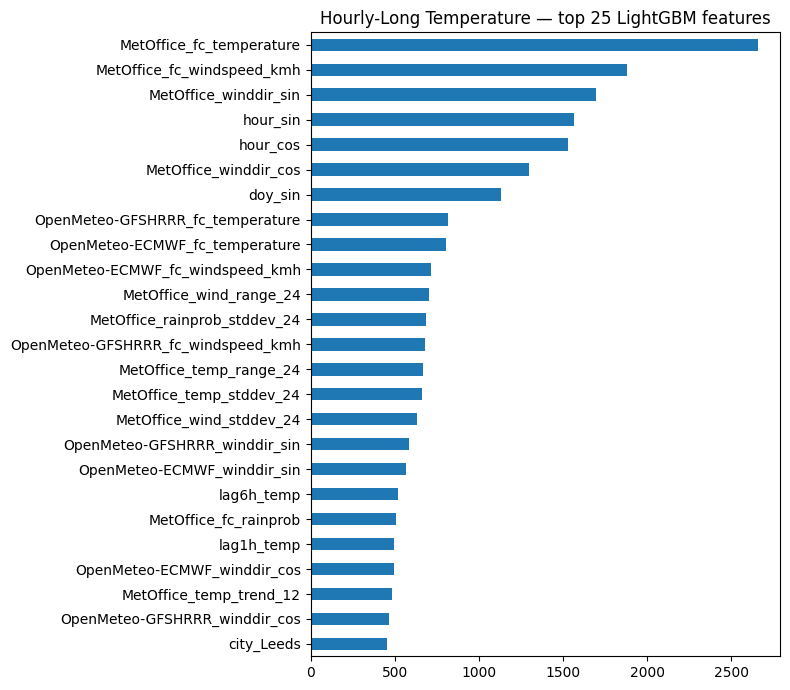

In [85]:
plot_top_features(temp_long, feature_cols_long,
                  'Hourly-Long Temperature — top 25 LightGBM features')

## Next steps

- **Rain & wind direction targets** — same pattern; rain volume probably wants two-stage (P(rain>0) × E[volume | rain]).
- **Daily ensemble** — parallel pipeline over `daily_forecast` joined to a daily aggregate of `observations`; `days_ahead` instead of `hours_ahead`.
- **Cross-validation** — once retention reaches ~3 months of data, switch from single time-based holdout to `TimeSeriesSplit` so seasonality is tested in both training and holdout windows.
- **Promote to nightly retrain** — once results are convincing, wrap the pipeline into `train_ensemble.py` and have `cron.py` invoke it daily after the data export.